## <span style="color: rgba(230, 0, 126, 1);"> Análisis Angélica </span> ##

# <span style="color: rgba(230, 0, 126, 1);"> DESAFÍO 2 </span> #

## <span style="color: rgba(230, 0, 126, 1);"> Analistas de Finanzas y Riesgo Creditício </span> ##

### <span style="color: rgba(230, 0, 126, 1);"> 1.- Enunciado </span> ###
- Los clientes con prestamos e hipotecas tienden a tener un saldo mediano mas bajo o mas riesgo de incumplimiento?
- Como tenemos que ajustar nuestras ofertas y estrategias de gestion de riesgos?

### <span style="color: rgba(230, 0, 126, 1);"> Importación de librerias para el análisis de datos </span> ###

In [51]:
# importación de librerias para el análisis de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### <span style="color: rgba(230, 0, 126, 1);"> Carga de datos desde archivo CSV original </span> ###

In [52]:
# la r al inicio cambia el sentido de la contrabarra en el path del repositorio local copiada directamente del explorador de windows. sep0";" indica como están separados los campos en el archivo csv"
df = pd.read_csv(
    r"C:\Users\mange\OneDrive\Cursos\Analisis de datos\Simulador\ProjecteData\Equip_18\Data\031125dataset.csv",
    sep=';'
)
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000
mean,9696.708514,41.312152,1535.302067,15.671885,370.811533,2.513055,51.420864,0.834241
std,6754.510024,11.927441,3292.261675,8.438361,347.467998,2.736740,109.471445,2.287959
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,4041.250000,32.000000,124.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,8081.500000,39.000000,556.000000,15.000000,254.000000,2.000000,-1.000000,0.000000
75%,17342.750000,49.000000,1708.000000,22.000000,494.000000,3.000000,9.000000,1.000000
max,21383.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### <span style="color: rgba(230, 0, 126, 1);"> EDA </span> ###

In [53]:
df['default'].value_counts()

default
no     15920
yes      242
Name: count, dtype: int64

In [54]:
df['balance'].describe()

count    16162.000000
mean      1535.302067
std       3292.261675
min      -6847.000000
25%        124.000000
50%        556.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

In [55]:
print("Nulos:", df['housing'].isna().sum())
print('"unknown":', (df['housing'] == 'unknown').sum())
print("\nDistribución de valores:")
print(df['housing'].value_counts(dropna=False))


Nulos: 0
"unknown": 0

Distribución de valores:
housing
no     8558
yes    7604
Name: count, dtype: int64


C:\Users\mange\AppData\Local\Temp\ipykernel_16232\1847034575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='balance', data=df,palette="Set2")


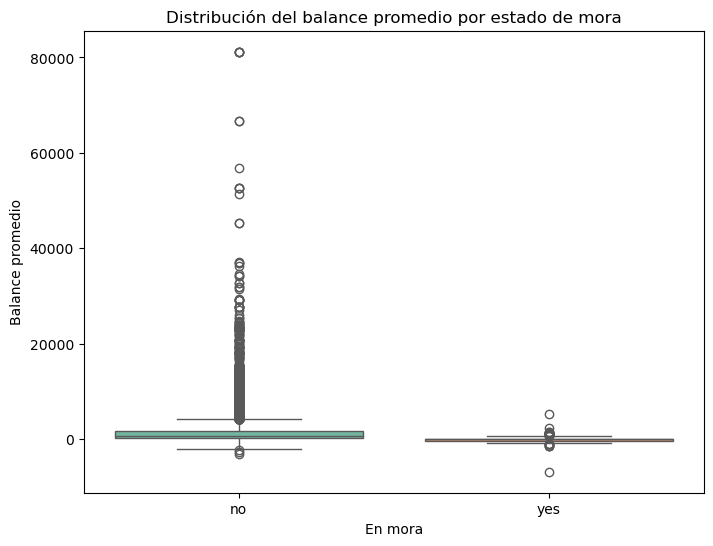

In [56]:
plt.figure(figsize=(8,6))
sns.boxplot(x='default', y='balance', data=df,palette="Set2")
plt.title("Distribución del balance promedio por estado de mora")
plt.xlabel("En mora")
plt.ylabel("Balance promedio")
plt.show();


### <span style="color: rgba(230, 0, 126, 1);"> Correlación </span> ###

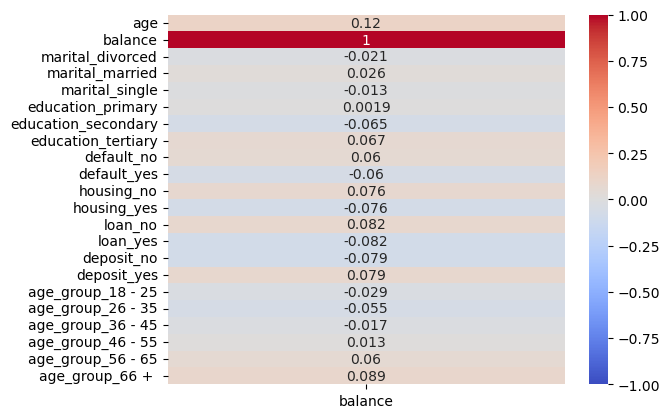

In [57]:
sns.heatmap(pd.get_dummies(df.drop(columns = ["id","contact","job","day","month", "duration","campaign","pdays","previous","poutcome"])).corr()[["balance"]],
            annot=True,           # esto me ayuda a mostrar los coeficientes
            cmap='coolwarm',      # paleta de colores
            vmin=-1, vmax=1);      # aca defino la escala de correlacion

In [ ]:
# correlación del campo housing con el resto de variables categóricas del dataset

# asignar un valor a las variables categoricas para poder realizar la correlación
df2 = df[['housing','age','job','marital','education','default','balance','loan']].copy()
# df2 = df[['housing','default','loan']].copy()
for c in df2.columns:
    df2[c] = df2[c].astype('category').cat.codes

sns.heatmap(df2.corr(), annot=True, linewidths=0.1,cmap='Blues',annot_kws={"size": 8})

In [58]:
neg = df[(df['balance'] < 0) & (df['default'] == 'yes')].shape[0]
no_neg = df[(df['balance'] >= 0) & (df['default'] == 'yes')].shape[0]
total_neg = df[df['balance'] < 0].shape[0]
total_no_neg = df[(df['balance'] >= 0) ].shape[0]

tasa_neg = neg / total_neg * 100
tasa_no_neg = no_neg / total_no_neg * 100




print(f"Número total de clientes con balance negativo: {total_neg:.2f}")
print(f"Número de clientes con balance negativo y mora: {neg:.2f}")
print()
print(f"Número total de clientes con balance positivo: {total_no_neg:.2f}")
print(f"Número de clientes con balance positivo y mora: {no_neg:.2f}")
print()
print(f"Tasa de mora con saldo negativo: {tasa_neg:.2f}%")
print(f"Tasa de mora con saldo positivo: {tasa_no_neg:.2f}%")


Número total de clientes con balance negativo: 1004.00
Número de clientes con balance negativo y mora: 111.00

Número total de clientes con balance positivo: 15158.00
Número de clientes con balance positivo y mora: 131.00

Tasa de mora con saldo negativo: 11.06%
Tasa de mora con saldo positivo: 0.86%


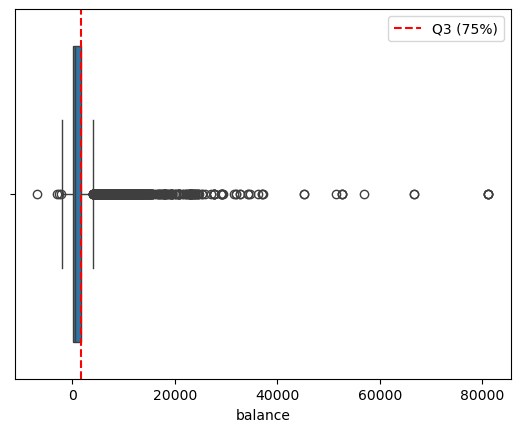

In [59]:

sns.boxplot(x=df['balance'])
plt.axvline(df['balance'].quantile(0.75), color='red', linestyle='--', label='Q3 (75%)')
plt.legend()
plt.show()


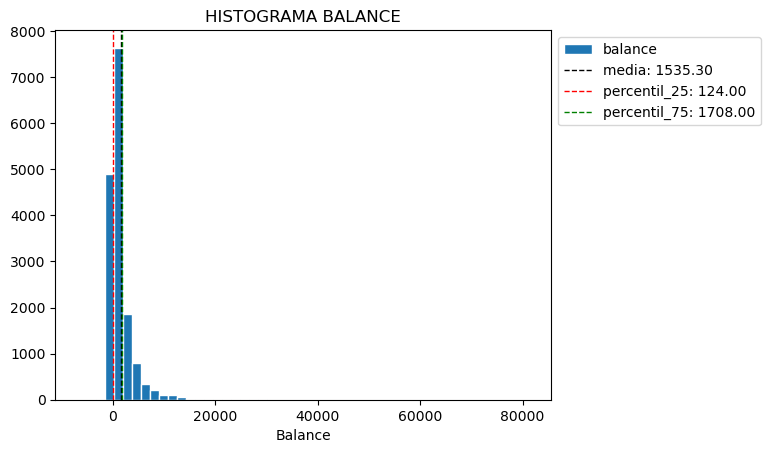

In [60]:
# Calculo las 4 medidas estadísticas básicas a partir del balance

media=df["balance"].mean()
mediana=df["balance"].median()
percentil_25=np.percentile(df["balance"],25)
percentil_75=np.percentile(df["balance"],75)

# Gráfica en la que se muestran el histográma que representa a la variable numérica "amount"
df["balance"].plot.hist(bins=50,edgecolor="white",label="balance")

# Lineas auxilliares sobre el gráfico
plt.axvline(media, color='black', linestyle='dashed', linewidth=1, label=f'media: {media:.2f}')
plt.axvline(percentil_25, color='red', linestyle='dashed', linewidth=1, label=f'percentil_25: {percentil_25:.2f}')
plt.axvline(percentil_75, color='green', linestyle='dashed', linewidth=1, label=f'percentil_75: {percentil_75:.2f}')

# Configuración de las etiquetas de los ejes y de la leyenda
plt.title("HISTOGRAMA BALANCE")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("Balance")
plt.ylabel("");

### <span style="color: rgba(230, 0, 126, 1);"> Cantidad de clientes por tipo de productos </span> ###

In [61]:



total_clientes = df.shape[0]

solo_housing = df[(df['housing'] == 'yes') & (df['loan'] == 'no')].shape[0]

solo_loan = df[(df['housing'] == 'no') & (df['loan'] == 'yes')].shape[0]


housing_loan = df[(df['housing'] == 'yes') & (df['loan'] == 'yes')].shape[0]


ninguno = df[(df['housing'] == 'no') & (df['loan'] == 'no')].shape[0]


resumen = pd.DataFrame({
    'Categoria': ['Solo Housing', 'Solo Loan', 'Housing y Loan', 'Ninguno'],
    'Clientes': [solo_housing, solo_loan, housing_loan, ninguno]
})


resumen['Porcentaje'] = (resumen['Clientes'] / total_clientes * 100).round(2)


print(f"Total clientes: {total_clientes}")
print(resumen)


Total clientes: 16162
        Categoria  Clientes  Porcentaje
0    Solo Housing      6395       39.57
1       Solo Loan       915        5.66
2  Housing y Loan      1209        7.48
3         Ninguno      7643       47.29


### <span style="color: rgba(230, 0, 126, 1);"> Histograma de Balance </span> ###

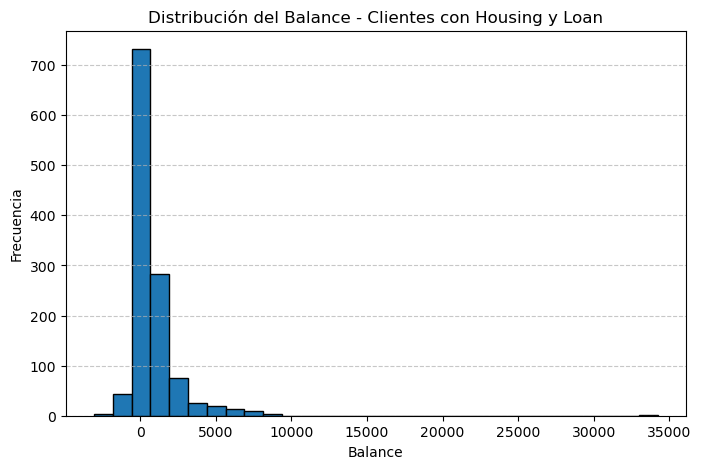

In [62]:

df_ambos = df[(df['housing'] == 'yes') & (df['loan'] == 'yes')]

# Crear histograma del balance
plt.figure(figsize=(8,5))
plt.hist(df_ambos['balance'], bins=30, edgecolor='black')
plt.title('Distribución del Balance - Clientes con Housing y Loan')
plt.xlabel('Balance')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### <span style="color: rgba(230, 0, 126, 1);"> Calculo tasas por rango y producto</span> ###

In [63]:
#Creacion de dataframes
df_ninguno = df[(df['housing'] == 'no') & (df['loan'] == 'no')].copy()
df_loan = df[(df['loan'] == 'yes') & (df['housing'] == 'no')].copy()
df_housing = df[(df['housing'] == 'yes') & (df['loan'] == 'no')].copy()
df_ambos = df[(df['housing'] == 'yes') & (df['loan'] == 'yes')].copy()

df_ninguno.loc[:, 'Grupo'] = 'Sin productos'
df_loan.loc[:, 'Grupo'] = 'Solo loan'
df_housing.loc[:, 'Grupo'] = 'Solo housing'
df_ambos.loc[:, 'Grupo'] = 'Housing y loan'

# hacer solo un dataframe
df_all = pd.concat([df_ninguno, df_loan, df_housing, df_ambos], ignore_index=True)

# Clasificar el balance en rangos
bins = [-float('inf'), -0.000001, 500, 2000, 10000]
labels = ['Negativo', 'Bajo', 'Medio', 'Alto']
df_all.loc[:, 'rango_balance'] = pd.cut(df_all['balance'], bins=bins, labels=labels)

# Crear tabla de frecuencias (conteo de mora y no mora)
tabla_frecuencias = (
    df_all.groupby(['Grupo', 'rango_balance', 'default'], observed=True)
          .size()
          .reset_index(name='conteo')
)

# formato ancho
tabla_frecuencias = (
    tabla_frecuencias
    .pivot_table(index=['Grupo', 'rango_balance'],
                 columns='default',
                 values='conteo',
                 fill_value=0,
                 observed=True)
    .reset_index()
)

# Renombrar columnas y calcular totales y tasas
tabla_frecuencias = tabla_frecuencias.rename(columns={'no': 'No mora', 'yes': 'Mora'})
tabla_frecuencias['Total'] = tabla_frecuencias['No mora'] + tabla_frecuencias['Mora']
tabla_frecuencias['Tasa mora (%)'] = (tabla_frecuencias['Mora'] / tabla_frecuencias['Total'] * 100).round(2)


print("📊 Tabla de frecuencias consolidada:")
print(tabla_frecuencias.to_string(index=False))


📊 Tabla de frecuencias consolidada:
         Grupo rango_balance  No mora  Mora  Total  Tasa mora (%)
Housing y loan      Negativo    177.0  22.0  199.0          11.06
Housing y loan          Bajo    496.0   9.0  505.0           1.78
Housing y loan         Medio    367.0   2.0  369.0           0.54
Housing y loan          Alto    134.0   0.0  134.0           0.00
 Sin productos      Negativo    118.0  17.0  135.0          12.59
 Sin productos          Bajo   3066.0  47.0 3113.0           1.51
 Sin productos         Medio   2326.0   8.0 2334.0           0.34
 Sin productos          Alto   1851.0   0.0 1851.0           0.00
  Solo housing      Negativo    489.0  56.0  545.0          10.28
  Solo housing          Bajo   2627.0  26.0 2653.0           0.98
  Solo housing         Medio   1960.0   6.0 1966.0           0.31
  Solo housing          Alto   1119.0   2.0 1121.0           0.18
     Solo loan      Negativo    109.0  16.0  125.0          12.80
     Solo loan          Bajo    417.0  2

### <span style="color: rgba(230, 0, 126, 1);"> Calculo Chi2</span> ###

In [64]:
from scipy.stats import chi2_contingency


resultados_chi2 = []

for rango in tabla_frecuencias['rango_balance'].unique():
    # Subconjunto por rango
    subset = tabla_frecuencias[tabla_frecuencias['rango_balance'] == rango]
    
    # Creamos la tabla de contingencia: filas = Grupo, columnas = Mora/No mora
    tabla_contingencia = subset[['Grupo', 'No mora', 'Mora']].set_index('Grupo')
    
    # Aplicar test Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    
    # Guardar resultados
    resultados_chi2.append({
        'Rango_balance': rango,
        'Chi2': round(chi2, 4),
        'p-valor': round(p, 6),
        'Grados_libertad': dof
    })

# Convertir a DataFrame para ver resultados juntos
resultados_chi2 = pd.DataFrame(resultados_chi2)

# Mostrar resultados
print("Resultados del test Chi-cuadrado por rango de balance:")
print(resultados_chi2.to_string(index=False))

# Interpretación simple
print("\n Interpretación:")
print("Si p-valor < 0.05 → existen diferencias significativas entre grupos (las tasas de mora difieren).")
print("Si p-valor >= 0.05 → no hay evidencia de diferencias significativas entre grupos.")


Resultados del test Chi-cuadrado por rango de balance:
Rango_balance    Chi2  p-valor  Grados_libertad
     Negativo  1.0486 0.789485                3
         Bajo 67.3433 0.000000                3
        Medio  5.4340 0.142638                3
         Alto  3.7276 0.292424                3

 Interpretación:
Si p-valor < 0.05 → existen diferencias significativas entre grupos (las tasas de mora difieren).
Si p-valor >= 0.05 → no hay evidencia de diferencias significativas entre grupos.


### <span style="color: rgba(230, 0, 126, 1);"> Calculo chi2 2X2</span> ###

In [65]:
from itertools import combinations
from scipy.stats import chi2_contingency
import pandas as pd

# Filtrar solo el rango de balance "Bajo"
df_bajo = tabla_frecuencias[tabla_frecuencias['rango_balance'] == 'Bajo']

# Crear todas las combinaciones posibles de grupos (pares)
pares = list(combinations(df_bajo['Grupo'].unique(), 2))

resultados_pares = []

for g1, g2 in pares:
    sub = df_bajo[df_bajo['Grupo'].isin([g1, g2])][['Grupo', 'No mora', 'Mora']]
    tabla = sub.set_index('Grupo')[['No mora', 'Mora']].values
    chi2, p, dof, _ = chi2_contingency(tabla)
    resultados_pares.append({
        'Comparación': f'{g1} vs {g2}',
        'Chi2': round(chi2, 4),
        'p-valor': p
    })

posthoc = pd.DataFrame(resultados_pares)
posthoc['Significativo (p<0.05)'] = posthoc['p-valor'] < 0.05

print("🔍 Comparaciones post hoc — rango de balance 'Bajo':")
print(posthoc.to_string(index=False))


🔍 Comparaciones post hoc — rango de balance 'Bajo':
                    Comparación    Chi2      p-valor  Significativo (p<0.05)
Housing y loan vs Sin productos  0.0706 7.905218e-01                   False
 Housing y loan vs Solo housing  1.8126 1.782013e-01                   False
    Housing y loan vs Solo loan 11.6776 6.325674e-04                    True
  Sin productos vs Solo housing  2.8061 9.390628e-02                   False
     Sin productos vs Solo loan 40.8665 1.629915e-10                    True
      Solo housing vs Solo loan 59.7244 1.091160e-14                    True


## <span style="color: rgba(230, 0, 126, 1);"> Análisis Marcos </span> ##

# <span style="color: rgba(230, 0, 126, 1);"> DESAFÍO 2 </span> #

## <span style="color: rgba(230, 0, 126, 1);"> Analistas de Finanzas y Riesgo Creditício </span> ##

### <span style="color: rgba(230, 0, 126, 1);"> 1.- Enunciado </span> ###
- Los clientes con préstamos e hipotecas tienden a tener un saldo medio más bajo o mayor riesgo de incumplimiento?
- Como deberíamos ajustar nuestras ofertas i estratégias de gestión de riesgos en función de estos hallazgos?

### <span style="color: rgba(230, 0, 126, 1);"> 2.- Importación de librerias para el análisis de datos </span> ###

In [ ]:
# importación de librerias para el análisis de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### <span style="color: rgba(230, 0, 126, 1);"> 3.- Carga de datos desde archivo CSV original </span> ###

In [ ]:
# la r al inicio cambia el sentido de la contrabarra en el path del repositorio local copiada directamente del explorador de windows. sep0";" indica como están separados los campos en el archivo csv"
df_m=pd.read_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251103_MNG_W02\031125dataset.csv",sep=";")
df_m.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000
mean,9696.708514,41.312152,1535.302067,15.671885,370.811533,2.513055,51.420864,0.834241
std,6754.510024,11.927441,3292.261675,8.438361,347.467998,2.736740,109.471445,2.287959
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,4041.250000,32.000000,124.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,8081.500000,39.000000,556.000000,15.000000,254.000000,2.000000,-1.000000,0.000000
75%,17342.750000,49.000000,1708.000000,22.000000,494.000000,3.000000,9.000000,1.000000
max,21383.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### <span style="color: rgba(230, 0, 126, 1);"> 4.- EDA </span> ###

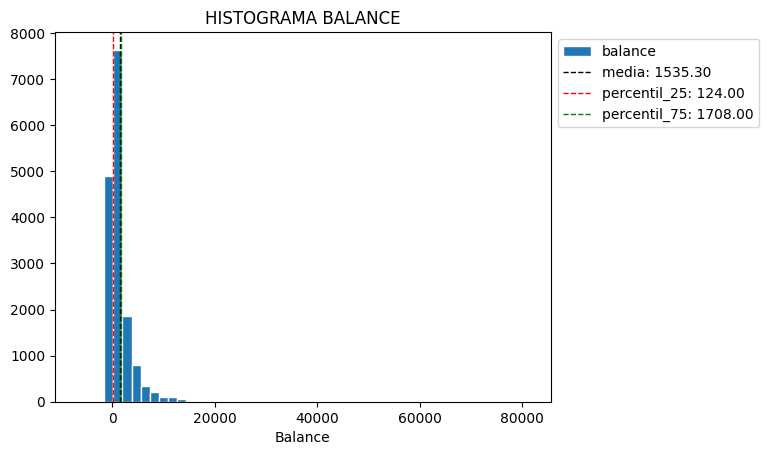

In [ ]:
# Calculo las 4 medidas estadísticas básicas a partir del balance

media=df_m["balance"].mean()
mediana=df_m["balance"].median()
percentil_25=np.percentile(df_m["balance"],25)
percentil_75=np.percentile(df_m["balance"],75)

# Gráfica en la que se muestran el histográma que representa a la variable numérica "amount"
df_m["balance"].plot.hist(bins=50,edgecolor="white",label="balance")

# Lineas auxilliares sobre el gráfico
plt.axvline(media, color='black', linestyle='dashed', linewidth=1, label=f'media: {media:.2f}')
plt.axvline(percentil_25, color='red', linestyle='dashed', linewidth=1, label=f'percentil_25: {percentil_25:.2f}')
plt.axvline(percentil_75, color='green', linestyle='dashed', linewidth=1, label=f'percentil_75: {percentil_75:.2f}')

# Configuración de las etiquetas de los ejes y de la leyenda
plt.title("HISTOGRAMA BALANCE")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("Balance")
plt.ylabel("");

<Axes: xlabel='default', ylabel='Count'>

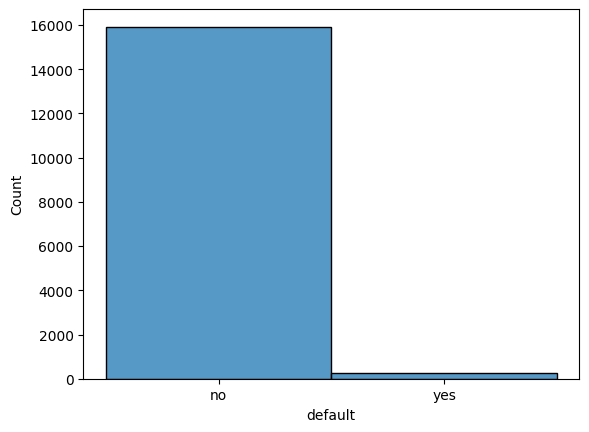

In [ ]:
# distribución del campo default
sns.histplot(data=df_m, x='default')

In [ ]:
# calcular la media de balance
media_balance=df_m['balance'].mean().round(2)
print(f'La media de BALANCE es:',media_balance)

La media de BALANCE es: 1535.3


In [ ]:
# filtrar balances
df_m_balanceNegativo=df_m.loc[df_m['balance']<0].shape
print(f'registros con balance negativo:',df_m_balanceNegativo)
df_m_balanceCero=df_m.loc[df_m['balance']==0].shape
print(f'registros con balance 0:',df_m_balanceCero)
df_m_balancePositivo=df_m.loc[df_m['balance']>0].shape
print(f'registros con balance positivo:',df_m_balancePositivo)

registros con balance negativo: (1004, 19)
registros con balance 0: (1117, 19)
registros con balance positivo: (14041, 19)


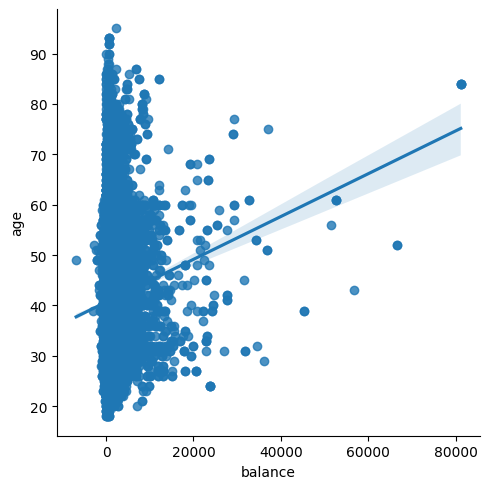

In [ ]:
# Busco si hay relación entre el balance y la edad de los clientes
sns.lmplot(data=df_m,x="balance",y="age")

In [ ]:
# distribución percentil (boxplot)

# Estilo visual de Seaborn
sns.set_context("notebook")     # Texto más grande (ideal para presentaciones)

# Crear figura más amplia y alta
plt.figure(figsize=(10, 8))

# Boxplot
sns.boxplot(
    data=df_m,
    x="default",
    y="balance",
    hue="balance_range",
    palette="Set1",  # Paleta de colores más amable
    width=0.5,       # Ancho de las cajas (un poco más delgado para claridad)
    fliersize=1      # Tamaño de los puntos outliers
)

# Títulos y etiquetas
plt.title("Distribución de balance según default y saldo", fontsize=10, weight='bold', pad=15)
plt.xlabel("Default", fontsize=10)
plt.ylabel("Balance", fontsize=10)

# Limitar eje Y si lo deseas
plt.ylim(-3000, 4500)

# Leyenda a la derecha, sin sobreponer el gráfico
plt.legend(
    title="Saldo",
    bbox_to_anchor=(1.02, 0.8),
    loc="upper left",
)

# Ajuste de márgenes
plt.tight_layout()

plt.show()

<Axes: >

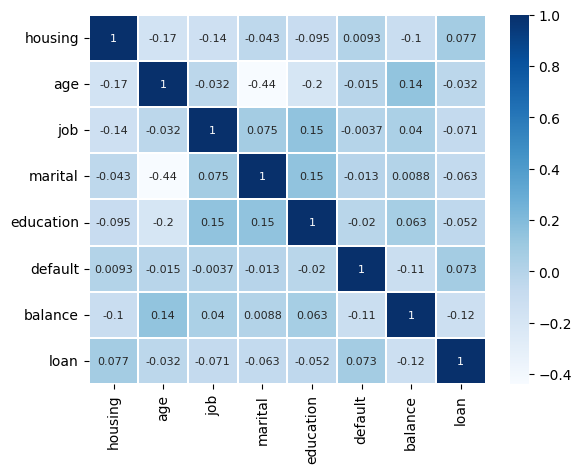

In [ ]:
# correlación del campo housing con el resto de variables categóricas del dataset

# asignar un valor a las variables categoricas para poder realizar la correlación
df_m2 = df_m[['housing','age','job','marital','education','default','balance','loan']].copy()
# df_m2 = df_m[['housing','default','loan']].copy()
for c in df_m2.columns:
    df_m2[c] = df_m2[c].astype('category').cat.codes

sns.heatmap(df_m2.corr(), annot=True, linewidths=0.1,cmap='Blues',annot_kws={"size": 8})

### <span style="color: rgba(230, 0, 126, 1);"> 5.- Categorizar los saldos: negativo- positivo </span> ###

In [ ]:
df_m.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000
mean,9696.708514,41.312152,1535.302067,15.671885,370.811533,2.513055,51.420864,0.834241
std,6754.510024,11.927441,3292.261675,8.438361,347.467998,2.736740,109.471445,2.287959
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,4041.250000,32.000000,124.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,8081.500000,39.000000,556.000000,15.000000,254.000000,2.000000,-1.000000,0.000000
75%,17342.750000,49.000000,1708.000000,22.000000,494.000000,3.000000,9.000000,1.000000
max,21383.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [ ]:
# definir los límites de los intervalos (bins)
# [-10000,2000) es bajo, [2000,10000) es medio y [10000,100000] es alto
intervalos=[-10000,0,100000]

# definir las etiquetas para cada intervalo
etiquetas=['negativo','positivo']

# creamos nueva columna con pd.cut()
df_m['balance_range']=pd.cut(df_m['balance'],bins=intervalos,labels=etiquetas,right=False)

# mover la nueva columna junto 'balance'
col = 'balance_range'
col_ref = 'balance'  # columna de referencia
cols = list(df_m.columns)
cols.insert(cols.index(col_ref) + 1, cols.pop(cols.index(col)))
df_m = df_m[cols]
df_m

,id,age,job,marital,education,default,balance,balance_range,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,1,59.0,administrative,married,secondary,no,2343,positivo,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,56 - 65
1,2,56.0,administrative,married,secondary,no,45,positivo,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,56 - 65
2,3,41.0,technician,married,secondary,no,1270,positivo,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,36 - 45
3,4,55.0,services,married,secondary,no,2476,positivo,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,46 - 55
4,5,54.0,administrative,married,tertiary,no,184,positivo,no,no,unknown,5,may,673,2,-1,0,unknown,yes,46 - 55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16157,21379,19.0,student,single,secondary,no,55,positivo,no,no,telephone,6,oct,89,2,193,1,other,no,18 - 25
16158,21380,40.0,technician,divorced,secondary,no,0,positivo,no,no,cellular,7,aug,674,2,-1,0,unknown,yes,36 - 45
16159,21381,36.0,blue-collar,married,secondary,no,723,positivo,yes,no,cellular,31,jul,101,2,-1,0,unknown,no,36 - 45
16160,21382,33.0,technician,single,tertiary,no,317,positivo,yes,no,cellular,4,jun,323,1,80,14,other,yes,26 - 35


### <span style="color: rgba(230, 0, 126, 1);"> 6.- Categorizar los saldos positivos: negativo- bajo - medio - alto </span> ###

In [ ]:
# definir los límites de los intervalos para los saldos positivos (bins)
# [-10000,0) es negativo, [0,500) es bajos, [500,2000] es medio y [2000,100000] es alto
intervalos_positivos=[-10000,0,500,2000,10000]

# definir las etiquetas para cada intervalo
etiquetas_positivos=['negativo','bajo','medio','alto']

# creamos nueva columna con pd.cut()
df_m['range_saldos_positivos']=pd.cut(df_m['balance'],bins=intervalos_positivos,labels=etiquetas_positivos,right=False)

# mover la nueva columna junto 'balance'
col = 'range_saldos_positivos'
col_ref = 'balance_range'  # columna de referencia
cols = list(df_m.columns)
cols.insert(cols.index(col_ref) + 1, cols.pop(cols.index(col)))
df_m = df_m[cols]
df_m

,id,age,job,marital,education,default,balance,balance_range,range_saldos_positivos,housing,...,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,1,59.0,administrative,married,secondary,no,2343,positivo,alto,yes,...,unknown,5,may,1042,1,-1,0,unknown,yes,56 - 65
1,2,56.0,administrative,married,secondary,no,45,positivo,bajo,no,...,unknown,5,may,1467,1,-1,0,unknown,yes,56 - 65
2,3,41.0,technician,married,secondary,no,1270,positivo,medio,yes,...,unknown,5,may,1389,1,-1,0,unknown,yes,36 - 45
3,4,55.0,services,married,secondary,no,2476,positivo,alto,yes,...,unknown,5,may,579,1,-1,0,unknown,yes,46 - 55
4,5,54.0,administrative,married,tertiary,no,184,positivo,bajo,no,...,unknown,5,may,673,2,-1,0,unknown,yes,46 - 55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16157,21379,19.0,student,single,secondary,no,55,positivo,bajo,no,...,telephone,6,oct,89,2,193,1,other,no,18 - 25
16158,21380,40.0,technician,divorced,secondary,no,0,positivo,bajo,no,...,cellular,7,aug,674,2,-1,0,unknown,yes,36 - 45
16159,21381,36.0,blue-collar,married,secondary,no,723,positivo,medio,yes,...,cellular,31,jul,101,2,-1,0,unknown,no,36 - 45
16160,21382,33.0,technician,single,tertiary,no,317,positivo,bajo,yes,...,cellular,4,jun,323,1,80,14,other,yes,26 - 35


### <span style="color: rgba(230, 0, 126, 1);"> 7.- Definir el estado de préstamos contratados: ninguno- loan - housing - ambos </span> ###

In [ ]:
# definir las etiquetas para diferenciar si el cliente tiene algún tipo de préstamo

df_m['prestamo']=np.where(
    (df_m.housing=='yes')&(df_m.loan=='yes'),'housing y loan',
    np.where(
        (df_m.housing=='yes')&(df_m.loan=='no'),'housing',
        np.where(
            (df_m.housing=='no')&(df_m.loan=='yes'),'loan',
            np.where(
                (df_m.housing=='no')&(df_m.loan=='no'),'ninguno',
                'otro'
            )
        )
    )
)

# mover la nueva columna despúes de 'loan'
col='prestamo'
col_ref='loan'  # columna de referencia
cols=list(df_m.columns)
cols.insert(cols.index(col_ref) + 1, cols.pop(cols.index(col)))
df_m=df_m[cols]
df_m


C:\Users\bnova\AppData\Local\Temp\ipykernel_19064\3856975943.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['prestamo']=np.where(


,id,age,job,marital,education,default,balance,balance_range,range_saldos_positivos,housing,...,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,1,59.0,administrative,married,secondary,no,2343,positivo,alto,yes,...,unknown,5,may,1042,1,-1,0,unknown,yes,56 - 65
1,2,56.0,administrative,married,secondary,no,45,positivo,bajo,no,...,unknown,5,may,1467,1,-1,0,unknown,yes,56 - 65
2,3,41.0,technician,married,secondary,no,1270,positivo,medio,yes,...,unknown,5,may,1389,1,-1,0,unknown,yes,36 - 45
3,4,55.0,services,married,secondary,no,2476,positivo,alto,yes,...,unknown,5,may,579,1,-1,0,unknown,yes,46 - 55
4,5,54.0,administrative,married,tertiary,no,184,positivo,bajo,no,...,unknown,5,may,673,2,-1,0,unknown,yes,46 - 55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16157,21379,19.0,student,single,secondary,no,55,positivo,bajo,no,...,telephone,6,oct,89,2,193,1,other,no,18 - 25
16158,21380,40.0,technician,divorced,secondary,no,0,positivo,bajo,no,...,cellular,7,aug,674,2,-1,0,unknown,yes,36 - 45
16159,21381,36.0,blue-collar,married,secondary,no,723,positivo,medio,yes,...,cellular,31,jul,101,2,-1,0,unknown,no,36 - 45
16160,21382,33.0,technician,single,tertiary,no,317,positivo,bajo,yes,...,cellular,4,jun,323,1,80,14,other,yes,26 - 35


### <span style="color: rgba(230, 0, 126, 1);"> 8.- Cálculo de tasas mora </span> ###

In [ ]:
# cálculo de la tasa de mora para clientes con préstamos Housing y Loan
totalClientesHousingLoanConDefault=len(df_m[(df_m['prestamo']=='housing y loan') & (df_m['default']=='yes')])
print(f'Nº de clientes con Housing y Loan que tienen deuda:',totalClientesHousingLoanConDefault)

totalClientesHousingLoan=len(df_m[df_m['prestamo']=='housing y loan'])
print(f'Nº de clientes con Housing y Loan:',totalClientesHousingLoan)

tasaMoraHousingLoan=totalClientesHousingLoanConDefault/totalClientesHousingLoan
tasaMoraHousingLoan=round(tasaMoraHousingLoan*100,2)
print(f'Tasa de mora para clientes con préstamos de Housing y Loan contratados:',tasaMoraHousingLoan,'%')

Nº de clientes con Housing y Loan que tienen deuda: 33
Nº de clientes con Housing y Loan: 1209
Tasa de mora para clientes con préstamos de Housing y Loan contratados: 2.73 %


In [ ]:
# cálculo de la tasa de mora para clientes con préstamos Housing
totalClientesHousingConDefault=len(df_m[(df_m['prestamo']=='housing') & (df_m['default']=='yes')])
print(f'Nº de clientes con Housing que tienen deuda:',totalClientesHousingConDefault)

totalClientesHousing=len(df_m[df_m['prestamo']=='housing'])
print(f'Nº de clientes con Housing:',totalClientesHousing)

tasaMoraHousing=totalClientesHousingConDefault/totalClientesHousing
tasaMoraHousing=round(tasaMoraHousing*100,2)
print(f'Tasa de mora para clientes con préstamos de Housing contratados:',tasaMoraHousing,'%')

Nº de clientes con Housing que tienen deuda: 90
Nº de clientes con Housing: 6395
Tasa de mora para clientes con préstamos de Housing contratados: 1.41 %


In [ ]:
# cálculo de la tasa de mora para clientes con préstamos Loan
totalClientesLoanConDefault=len(df_m[(df_m['prestamo']=='loan') & (df_m['default']=='yes')])
print(f'Nº de clientes con Loan que tienen deuda:',totalClientesLoanConDefault)

totalClientesLoan=len(df_m[df_m['prestamo']=='loan'])
print(f'Nº de clientes con Loan:',totalClientesLoan)

tasaMoraLoan=totalClientesLoanConDefault/totalClientesLoan
tasaMoraLoan=round(tasaMoraLoan*100,2)
print(f'Tasa de mora para clientes con préstamos de Loan contratados:',tasaMoraLoan,'%')

Nº de clientes con Loan que tienen deuda: 47
Nº de clientes con Loan: 915
Tasa de mora para clientes con préstamos de Loan contratados: 5.14 %


In [ ]:
# cálculo de la tasa de mora para clientes sin préstamos
totalClientesSinPrestamosConDefault=len(df_m[(df_m['prestamo']=='ninguno') & (df_m['default']=='yes')])
print(f'Nº de clientes sin préstamos que tienen deuda:',totalClientesSinPrestamosConDefault)

totalClientesSinPrestamos=len(df_m[df_m['prestamo']=='ninguno'])
print(f'Nº de clientes sin préstamos:',totalClientesSinPrestamos)

tasaMoraSinPrestamos=totalClientesSinPrestamosConDefault/totalClientesSinPrestamos
tasaMoraSinPrestamos=round(tasaMoraSinPrestamos*100,2)
print(f'Tasa de mora para clientes sin préstamos contratados:',tasaMoraSinPrestamos,'%')

Nº de clientes sin préstamos que tienen deuda: 72
Nº de clientes sin préstamos: 7643
Tasa de mora para clientes sin préstamos contratados: 0.94 %


### <span style="color: rgba(230, 0, 126, 1);"> 9.- Cálculo de tasas balance </span> ###

In [ ]:
# cálculo de la tasa de balance Alto para clientes con préstamos Housing y Loan
totalClientesHousingLoanAlto=len(df_m[(df_m['prestamo']=='housing y loan') & (df_m['range_saldos_positivos']=='alto')])
print(f'Nº de clientes con Housing y Loan que tienen saldo alto:',totalClientesHousingLoanAlto)

totalClientesHousingLoan=len(df_m[df_m['prestamo']=='housing y loan'])
print(f'Nº de clientes con Housing y Loan:',totalClientesHousingLoan)

tasaBalanceHousingLoanAlto=totalClientesHousingLoanAlto/totalClientesHousingLoan
tasaBalanceHousingLoanAlto=round(tasaBalanceHousingLoanAlto*100,2)
print(f'Tasa de balance para clientes con préstamos de Housing y Loan contratados y saldos altos:',tasaBalanceHousingLoanAlto,'%')

Nº de clientes con Housing y Loan que tienen saldo alto: 134
Nº de clientes con Housing y Loan: 1209
Tasa de balance para clientes con préstamos de Housing y Loan contratados y saldos altos: 11.08 %


In [ ]:
# cálculo de la tasa de balance Medio para clientes con préstamos Housing y Loan
totalClientesHousingLoanMedio=len(df_m[(df_m['prestamo']=='housing y loan') & (df_m['range_saldos_positivos']=='medio')])
print(f'Nº de clientes con Housing y Loan que tienen saldo medio:',totalClientesHousingLoanMedio)

totalClientesHousingLoan=len(df_m[df_m['prestamo']=='housing y loan'])
print(f'Nº de clientes con Housing y Loan:',totalClientesHousingLoan)

tasaBalanceHousingLoanMedio=totalClientesHousingLoanMedio/totalClientesHousingLoan
tasaBalanceHousingLoanMedio=round(tasaBalanceHousingLoanMedio*100,2)
print(f'Tasa de balance para clientes con préstamos de Housing y Loan contratados y saldos medios:',tasaBalanceHousingLoanMedio,'%')

Nº de clientes con Housing y Loan que tienen saldo medio: 369
Nº de clientes con Housing y Loan: 1209
Tasa de balance para clientes con préstamos de Housing y Loan contratados y saldos medios: 30.52 %


In [ ]:
# cálculo de la tasa de balance Bajo para clientes con préstamos Housing y Loan
totalClientesHousingLoanBajo=len(df_m[(df_m['prestamo']=='housing y loan') & (df_m['range_saldos_positivos']=='bajo')])
print(f'Nº de clientes con Housing y Loan que tienen saldo bajo:',totalClientesHousingLoanBajo)

totalClientesHousingLoan=len(df_m[df_m['prestamo']=='housing y loan'])
print(f'Nº de clientes con Housing y Loan:',totalClientesHousingLoan)

tasaBalanceHousingLoanBajo=totalClientesHousingLoanBajo/totalClientesHousingLoan
tasaBalanceHousingLoanBajo=round(tasaBalanceHousingLoanBajo*100,2)
print(f'Tasa de balance para clientes con préstamos de Housing y Loan contratados y saldos bajos:',tasaBalanceHousingLoanBajo,'%')

Nº de clientes con Housing y Loan que tienen saldo bajo: 505
Nº de clientes con Housing y Loan: 1209
Tasa de balance para clientes con préstamos de Housing y Loan contratados y saldos bajos: 41.77 %


In [ ]:
# cálculo de la tasa de balance Negativo para clientes con préstamos Housing y Loan
totalClientesHousingLoanNegativo=len(df_m[(df_m['prestamo']=='housing y loan') & (df_m['range_saldos_positivos']=='negativo')])
print(f'Nº de clientes con Housing y Loan que tienen saldo negativo:',totalClientesHousingLoanNegativo)

totalClientesHousingLoan=len(df_m[df_m['prestamo']=='housing y loan'])
print(f'Nº de clientes con Housing y Loan:',totalClientesHousingLoan)

tasaBalanceHousingLoanNegativo=totalClientesHousingLoanNegativo/totalClientesHousingLoan
tasaBalanceHousingLoanNegativo=round(tasaBalanceHousingLoanNegativo*100,2)
print(f'Tasa de balance para clientes con préstamos de Housing y Loan contratados y saldos negativos:',tasaBalanceHousingLoanNegativo,'%')

Nº de clientes con Housing y Loan que tienen saldo negativo: 199
Nº de clientes con Housing y Loan: 1209
Tasa de balance para clientes con préstamos de Housing y Loan contratados y saldos negativos: 16.46 %


### <span style="color: rgba(230, 0, 126, 1);"> 10.- Exportación a csv </span> ###

In [ ]:
df_m.to_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251103_MNG_W02\031125_PythonToPowerBI.csv",sep=";",index=False)